<a href="https://colab.research.google.com/github/kari1020/codigo1/blob/main/S19_Analisis_Exploratorio_Portafolios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📝 Actividad de Evaluación: Análisis Exploratorio de Portafolios (10%)

**Instrucciones:**
1. Resuelve cada uno de los puntos solicitados utilizando código de Python limpio y ordenado.
2. No olvides acompañar cada visualización con su respectiva **interpretación analítica** (recuerda la regla de oro: qué observas y qué significa).
3. Puedes realizar esta actividad de forma individual o en parejas (según las indicaciones del docente).

---

## 🏦 Paso 1: Selección y Descarga de Datos

1. Selecciona **3 activos financieros** diferentes a los utilizados en la clase (evita usar AAPL, MSFT, GOOGL, AMZN o NVDA).
2. Descarga los datos históricos utilizando `yfinance` para el periodo del **1 de enero de 2024** al **1 de enero de 2026**.
3. Muestra las primeras 5 filas del DataFrame resultante para validar la descarga.

In [1]:
!pip install yfinance -q
import yfinance as yf
# Escribe aquí tu código para descargar los datos de tus 3 activos elegidos

In [3]:
activos=["UPS","QCOM","UNH"]
df=yf.download(activos,start="2024-01-01",end="2026-01-01")
df.head()

/tmp/ipykernel_2902/931919427.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df=yf.download(activos,start="2024-01-01",end="2026-01-01")
[*********************100%***********************]  3 of 3 completed


Price            Close                                High              \
Ticker            QCOM         UNH         UPS        QCOM         UNH   
Date                                                                     
2024-01-02  132.436523  508.214844  134.933273  134.297039  508.516326   
2024-01-03  129.952682  510.749573  134.251541  131.170982  515.234826   
2024-01-04  128.602127  513.943970  133.782852  129.697662  517.317385   
2024-01-05  129.131012  506.367859  135.257111  130.396550  515.432685   
2024-01-08  131.303192  505.557587  136.279709  131.416518  509.072311   

Price                          Low                                Open  \
Ticker             UPS        QCOM         UNH         UPS        QCOM   
Date                                                                     
2024-01-02  136.791020  131.067112  496.275985  133.194843  134.287600   
2024-01-03  135.742846  129.376584  508.346687  133.092584  131.170982   
2024-01-04  134.916246  127.440490  511.663643  133.288590  127.912702   
2024-01-05  135.887724  128.299929  502.928477  133.152239  128.592698   
2024-01-08  136.339367  129.046021  497.529255  134.200402  129.376575   

Price                                Volume                    
Ticker             UNH         UPS     QCOM      UNH      UPS  
Date                                                           
2024-01-02  496.436216  133.740235  8495800  3415700  4363800  
2024-01-03  511.701238  134.021463  8133300  2891400  3257200  
2024-01-04  513.548224  133.833981  6770300  2994400  3173400  
2024-01-05  515.432685  133.297107  6827300  2815400  2537300  
2024-01-08  508.271387  135.129281  7729400  2648900  2469500

## 📈 Paso 2: Análisis de Precios de Cierre y Normalización

1. Filtra y extrae únicamente los precios de cierre (`Close`).
2. Grafica en una sola figura la evolución temporal de los precios originales de tus 3 activos.
3. Realiza la normalización (base 100 en el primer registro) y grafica nuevamente las series en otra figura.

### 💬 Pregunta de interpretación #1:
Al comparar ambos gráficos (precios reales vs. precios normalizados), ¿por qué es metodológicamente más correcto utilizar el gráfico normalizado para comparar el rendimiento histórico de los activos? Explica la diferencia en el comportamiento visual observado.

Ticker,QCOM,UNH,UPS
Date,,,
2024-01-02,132.436523,508.214844,134.933273
2024-01-03,129.952682,510.749573,134.251541
2024-01-04,128.602127,513.943970,133.782852
2024-01-05,129.131012,506.367859,135.257111
2024-01-08,131.303192,505.557587,136.279709


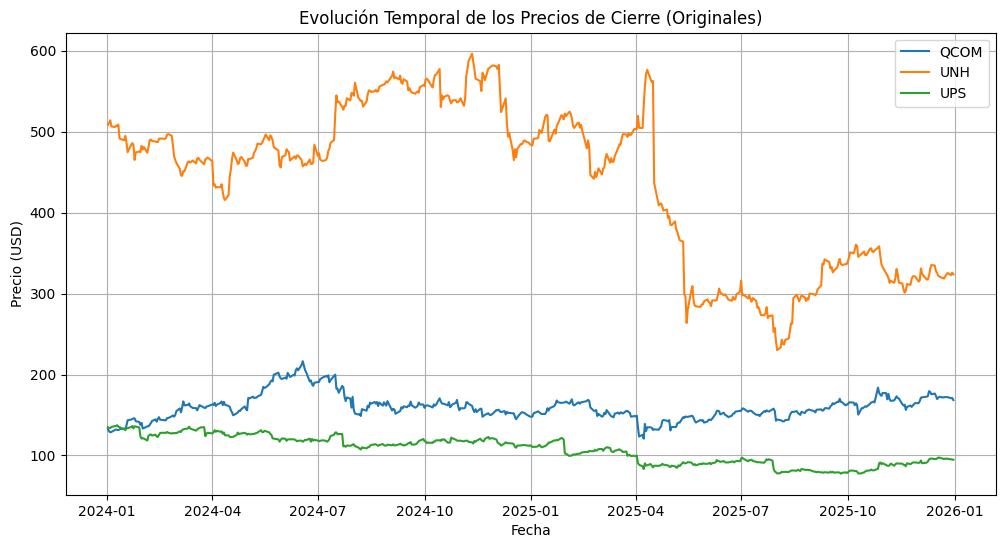

In [15]:
import matplotlib.pyplot as plt

# 1. Extraer los precios de cierre
precios_cierre = df['Close']
display(precios_cierre.head())

# 2. Graficar precios originales
plt.figure(figsize=(12, 6))
plt.plot(precios_cierre.index, precios_cierre['QCOM'], label='QCOM')
plt.plot(precios_cierre.index, precios_cierre['UNH'], label='UNH')
plt.plot(precios_cierre.index, precios_cierre['UPS'], label='UPS')

plt.title('Evolución Temporal de los Precios de Cierre (Originales)')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True)
plt.show()

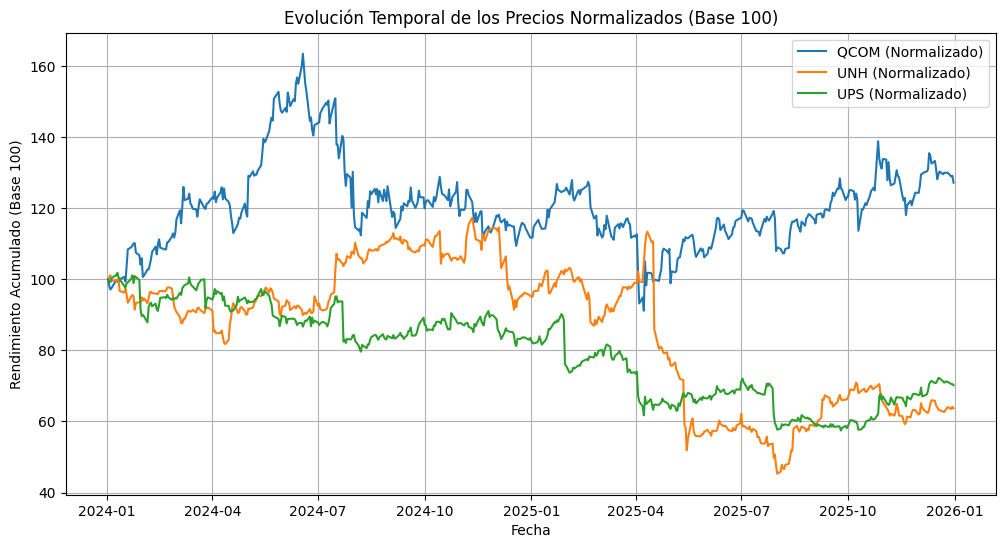

In [16]:
# 3. Normalizar (base 100 en el primer registro) y graficar en otra figura
precios_normalizados = (precios_cierre / precios_cierre.iloc[0]) * 100

plt.figure(figsize=(12, 6))
plt.plot(precios_normalizados.index, precios_normalizados['QCOM'], label='QCOM (Normalizado)')
plt.plot(precios_normalizados.index, precios_normalizados['UNH'], label='UNH (Normalizado)')
plt.plot(precios_normalizados.index, precios_normalizados['UPS'], label='UPS (Normalizado)')

plt.title('Evolución Temporal de los Precios Normalizados (Base 100)')
plt.xlabel('Fecha')
plt.ylabel('Rendimiento Acumulado (Base 100)')
plt.legend()
plt.grid(True)
plt.show()

## 🔄 Paso 3: Cálculo y Distribución de Rendimientos

1. Calcula los rendimientos diarios de los activos y elimina los valores nulos (`NaN`).
2. Genera un **histograma* para el activo que consideres que haya sido el más volátil.
3. Diseña un **Boxplot** comparativo que muestre los rendimientos diarios de tus 3 activos simultáneamente.

### 💬 Pregunta de interpretación #2:
Observando el Boxplot y el Histograma:
- ¿Qué activo presenta la mayor dispersión (caja más amplia o bigotes más largos) y qué te dice esto sobre su riesgo?
- ¿Identificas valores atípicos (outliers)? ¿Qué representan estos puntos en el contexto de la historia económica reciente de estas empresas?

Ticker,QCOM,UNH,UPS
Date,,,
2024-01-03,-0.018755,0.004988,-0.005052
2024-01-04,-0.010393,0.006254,-0.003491
2024-01-05,0.004113,-0.014741,0.011020
2024-01-08,0.016822,-0.001600,0.007560
2024-01-09,0.006186,0.003448,0.000125


El activo más volátil es: UNH con una desviación estándar diaria de 0.0243


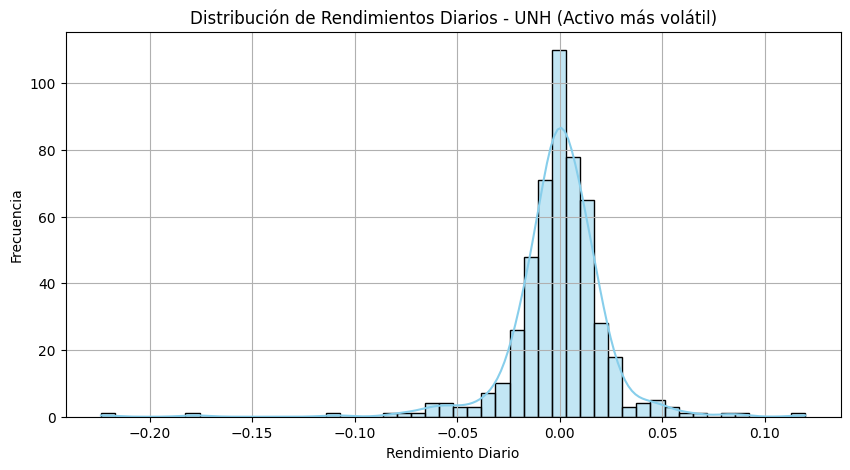

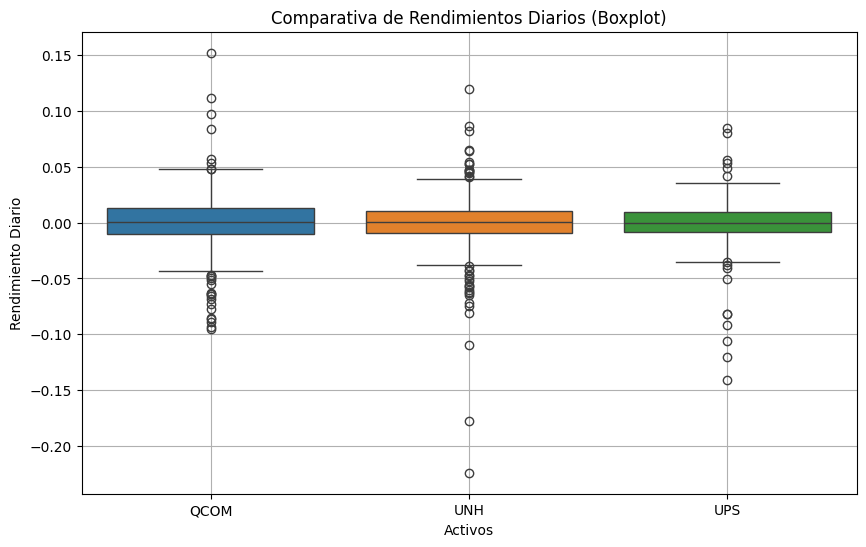

In [17]:
import numpy as np
import seaborn as sns

# 1. Calcular rendimientos diarios de los activos y eliminar los valores nulos (NaN)
rendimientos = precios_cierre.pct_change().dropna()
display(rendimientos.head())

# Identificar el activo más volátil usando la desviación estándar
volatilidad = rendimientos.std()
activo_mas_volatil = volatilidad.idxmax()
print(f"El activo más volátil es: {activo_mas_volatil} con una desviación estándar diaria de {volatilidad.max():.4f}")

# 2. Histograma con el activo más volátil
plt.figure(figsize=(10, 5))
sns.histplot(rendimientos[activo_mas_volatil], kde=True, color='skyblue', bins=50)
plt.title(f'Distribución de Rendimientos Diarios - {activo_mas_volatil} (Activo más volátil)')
plt.xlabel('Rendimiento Diario')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

# 3. Boxplot comparativo de rendimientos diarios
plt.figure(figsize=(10, 6))
sns.boxplot(data=rendimientos)
plt.title('Comparativa de Rendimientos Diarios (Boxplot)')
plt.xlabel('Activos')
plt.ylabel('Rendimiento Diario')
plt.grid(True)
plt.show()

## 📊 Paso 4: Asociación y Correlación

1. Calcula la matriz de correlación de Pearson para los rendimientos de tus 3 activos.
2. Grafica un **mapa de calor (Heatmap)**.

### 💬 Pregunta de interpretación #3:
- ¿Existe alguna correlación fuerte (cercana a 1 o -1) entre alguno de tus activos?
- Si tuvieras que armar un portafolio de inversión buscando la **diversificación** (minimizar el riesgo conjunto), ¿qué par de activos elegirías de acuerdo a tus resultados y por qué?

Ticker,QCOM,UNH,UPS
Ticker,,,
QCOM,1.000000,0.083523,0.298869
UNH,0.083523,1.000000,0.118954
UPS,0.298869,0.118954,1.000000


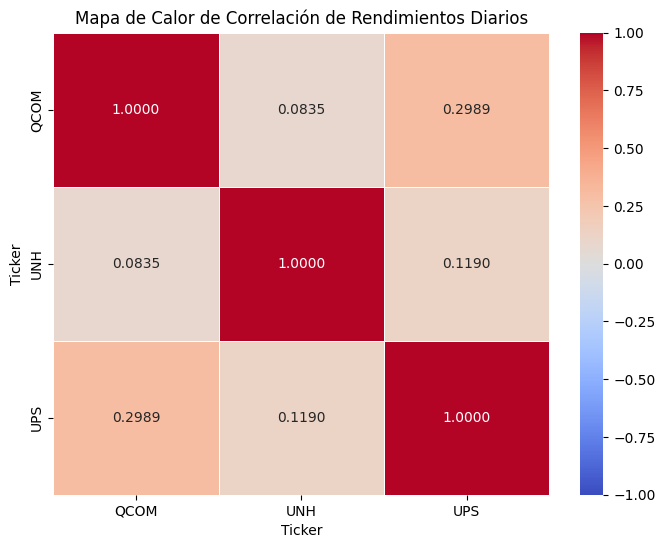

In [21]:
# 1. Calcular matriz de correlación de Pearson
matriz_corr = rendimientos.corr(method='pearson')
display(matriz_corr)

# 2. Dibujar el Heatmap utilizando Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".4f", linewidths=0.5)
plt.title('Mapa de Calor de Correlación de Rendimientos Diarios')
plt.show()

## 🧮 Paso 5: Estadísticas Descriptivas y Conclusión

1. Genera un DataFrame de resumen estadístico que incluya para cada activo: Media, Mediana, Desviación Estándar, Mínimo y Máximo de los rendimientos diarios.
2. Escribe una breve conclusión final dirigida a un inversionista ficticio, interpretando los estadísticos clave obtenidos.

In [24]:
# 1. Generar resumen de estadísticas descriptivas (Media, Mediana, Desviación estándar, Mínimo y Máximo)
stats_resumen = rendimientos.describe().loc[['mean', '50%', 'std', 'min', 'max']]
stats_resumen.index = ['Media', 'Mediana (50%)', 'Desviación Estándar', 'Mínimo', 'Máximo']

# Mostrar la tabla formateada
display(stats_resumen)

Ticker,QCOM,UNH,UPS
Media,0.000770,-0.000591,-0.000526
Mediana (50%),0.000879,0.000348,0.000000
Desviación Estándar,0.024101,0.024345,0.018767
Mínimo,-0.095145,-0.223797,-0.141127
Máximo,0.151853,0.119784,0.084204
